# Classification Enhancement GAN (CE-GAN) for KLSG Seabed Dataset

This notebook implements a **Classification Enhancement GAN** to address class imbalance in the KLSG seabed dataset by generating synthetic samples for under-represented classes — specifically **Class 0 (68 samples)**.

---

### Dataset Class Distribution
| Class | Count | Label |
|-------|-------|-------|
| Class 0 | 68 | Under-represented (target for generation) |
| Class 1 | 14 | Severely under-represented |
| Class 2 | 46 | Under-represented |
| Class 3 | 277 | Majority class |

### Dataset Structure
```
KLSG/
├── train/
│   ├── images/
│   └── labels/
├── val/
│   ├── images/
│   └── labels/
└── test/
    ├── images/
    └── labels/
```

### Pipeline Overview
1. **Data Loading & EDA** — Load KLSG dataset, visualize class distribution
2. **Preprocessing** — Extract Class 0 patches, normalize
3. **CE-GAN Architecture** — Conditional Generator + Discriminator with classification head
4. **Training** — Adversarial + Classification loss
5. **Evaluation** — FID score, visual inspection, downstream classifier comparison
6. **Augmented Dataset Export** — Save synthetic images + updated labels

## Cell 1: Environment Setup & GPU Verification

In [21]:
import torch
print(torch.__version__)               # e.g. 2.3.0+cu124
print(torch.cuda.is_available())       # Must be True
print(torch.cuda.get_device_name(0))   # Your GPU name

2.6.0+cu124
True
NVIDIA RTX 4000 Ada Generation


In [2]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Install required packages if not present
required = ['torch', 'torchvision', 'numpy', 'matplotlib', 'seaborn',
            'scikit-learn', 'Pillow', 'tqdm', 'scipy', 'pandas', 'opencv-python']

for pkg in required:
    try:
        __import__(pkg.replace('-', '_').split('==')[0])
    except ImportError:
        print(f'Installing {pkg}...')
        install(pkg)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import cv2
import os, json, shutil
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from scipy import linalg
from sklearn.metrics import classification_report, confusion_matrix
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ── GPU Check ──────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('=' * 60)
print(f'  PyTorch version : {torch.__version__}')
print(f'  Device          : {device}')
if torch.cuda.is_available():
    print(f'  GPU             : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
    print(f'  CUDA version    : {torch.version.cuda}')
    torch.backends.cudnn.benchmark = True
else:
    print('  ⚠ No GPU found — training will be slow on CPU')
print('=' * 60)

Installing scikit-learn...
Installing Pillow...
Installing opencv-python...
  PyTorch version : 2.6.0+cu124
  Device          : cuda
  GPU             : NVIDIA RTX 4000 Ada Generation
  VRAM            : 21.47 GB
  CUDA version    : 12.4


## Cell 2: Configuration & Hyperparameters

In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              CONFIGURATION — Edit paths here                 ║
# ╚══════════════════════════════════════════════════════════════╝

CFG = {
    # ── Dataset ──────────────────────────────────────────────────
    'data_root'        : './KLSG',           # Root directory of KLSG dataset
    'output_dir'       : './cegan_outputs',  # All outputs saved here
    'generated_dir'    : './cegan_outputs/generated_class0',
    'augmented_dir'    : './cegan_outputs/augmented_dataset',

    # ── Target class ─────────────────────────────────────────────
    'target_class'     : 0,
    'n_classes'        : 4,
    'target_n_samples' : 277,

    # ── Known class distribution ─────────────────────────────────
    'class_counts'     : {0: 68, 1: 14, 2: 46, 3: 277},

    # ── Image ────────────────────────────────────────────────────
    'img_size'         : 128,
    'channels'         : 3,

    # ── GAN Architecture ─────────────────────────────────────────
    'latent_dim'       : 128,
    'ngf'              : 64,
    'ndf'              : 64,
    'embed_dim'        : 32,

    # ── Training (tuned for small dataset / mode-collapse prevention) ──
    'epochs'           : 800,
    'batch_size'       : 8,        # FIXED: was 16 — too large for 68 samples
    'lr_g'             : 1e-4,     # FIXED: was 2e-4 — lower so D doesn't overpower G
    'lr_d'             : 4e-5,     # FIXED: was 1e-4 — D must be slower than G
    'beta1'            : 0.0,      # FIXED: was 0.5 — 0.0 is standard for WGAN-GP
    'beta2'            : 0.9,      # FIXED: was 0.999 — 0.9 recommended for WGAN-GP
    'n_critic'         : 5,        # FIXED: was 2 — WGAN-GP standard is 5
    'lambda_cls'       : 1.0,      # FIXED: was 10.0 — too high overwhelmed adversarial signal
    'lambda_gp'        : 10.0,
    'label_smooth'     : 0.0,      # Disabled — not needed with WGAN

    # ── Logging ──────────────────────────────────────────────────
    'save_interval'    : 25,       # Check progress more frequently
    'log_interval'     : 10,
    'seed'             : 42,
}

# Reproducibility
torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG['seed'])

# Create output directories
for d in [CFG['output_dir'], CFG['generated_dir'], CFG['augmented_dir']]:
    Path(d).mkdir(parents=True, exist_ok=True)

print('Configuration loaded:')
for k, v in CFG.items():
    print(f'  {k:20s}: {v}')


Configuration loaded:
  data_root           : ./KLSG
  output_dir          : ./cegan_outputs
  generated_dir       : ./cegan_outputs/generated_class0
  augmented_dir       : ./cegan_outputs/augmented_dataset
  target_class        : 0
  n_classes           : 4
  target_n_samples    : 277
  class_counts        : {0: 68, 1: 14, 2: 46, 3: 277}
  img_size            : 128
  channels            : 3
  latent_dim          : 128
  ngf                 : 64
  ndf                 : 64
  embed_dim           : 32
  epochs              : 800
  batch_size          : 8
  lr_g                : 0.0001
  lr_d                : 4e-05
  beta1               : 0.0
  beta2               : 0.9
  n_critic            : 5
  lambda_cls          : 1.0
  lambda_gp           : 10.0
  label_smooth        : 0.0
  save_interval       : 25
  log_interval        : 10
  seed                : 42


## Cell 3: Dataset Loading & Exploratory Data Analysis

In [4]:
def parse_yolo_label(label_path, img_w, img_h):
    """Parse YOLO-format label file → list of (class_id, x1, y1, x2, y2)."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f.read().strip().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            cls = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = int((cx - bw / 2) * img_w)
            y1 = int((cy - bh / 2) * img_h)
            x2 = int((cx + bw / 2) * img_w)
            y2 = int((cy + bh / 2) * img_h)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(img_w, x2), min(img_h, y2)
            if x2 > x1 and y2 > y1:
                boxes.append((cls, x1, y1, x2, y2))
    return boxes


def load_dataset_info(data_root):
    """Scan all splits and return a DataFrame with one row per bounding box."""
    records = []
    data_root = Path(data_root)
    splits = [d for d in ['train', 'val', 'test'] if (data_root / d).exists()]

    if not splits:
        print(f'⚠  No split folders found under {data_root}')
        print('   Expected: train/, val/, test/ each with images/ and labels/')
        print('   Using synthetic demo data for illustration.')
        return None, None

    img_paths_by_class = defaultdict(list)  # class_id → [(img_path, box)]

    for split in splits:
        img_dir   = data_root / split / 'images'
        lbl_dir   = data_root / split / 'labels'
        img_files = sorted(list(img_dir.glob('*.jpg')) +
                           list(img_dir.glob('*.png')) +
                           list(img_dir.glob('*.jpeg')))

        for img_path in tqdm(img_files, desc=f'Loading {split}', leave=False):
            lbl_path = lbl_dir / (img_path.stem + '.txt')
            img = Image.open(img_path)
            w, h = img.size
            boxes = parse_yolo_label(str(lbl_path), w, h)
            if not boxes:
                continue
            for cls, x1, y1, x2, y2 in boxes:
                records.append({
                    'split': split,
                    'img_path': str(img_path),
                    'lbl_path': str(lbl_path),
                    'class_id': cls,
                    'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                    'img_w': w, 'img_h': h,
                })
                img_paths_by_class[cls].append({
                    'img_path': str(img_path),
                    'box': (x1, y1, x2, y2)
                })

    df = pd.DataFrame(records)
    return df, img_paths_by_class


print('Scanning KLSG dataset...')
df_info, img_paths_by_class = load_dataset_info(CFG['data_root'])

if df_info is not None and len(df_info) > 0:
    print(f'\nLoaded {len(df_info)} bounding box annotations')
    print('\nClass distribution across all splits:')
    print(df_info['class_id'].value_counts().sort_index())
    actual_counts = df_info['class_id'].value_counts().sort_index().to_dict()
    CFG['class_counts'] = actual_counts
else:
    print('Dataset not found at specified path — using known class counts from config.')
    # Continue with config counts
    df_info = pd.DataFrame([
        {'class_id': cls, 'count': cnt}
        for cls, cnt in CFG['class_counts'].items()
    ])

Scanning KLSG dataset...



Loaded 947 bounding box annotations

Class distribution across all splits:
class_id
0    105
1    208
2    178
3    456
Name: count, dtype: int64


## Cell 4: Class Distribution Visualization

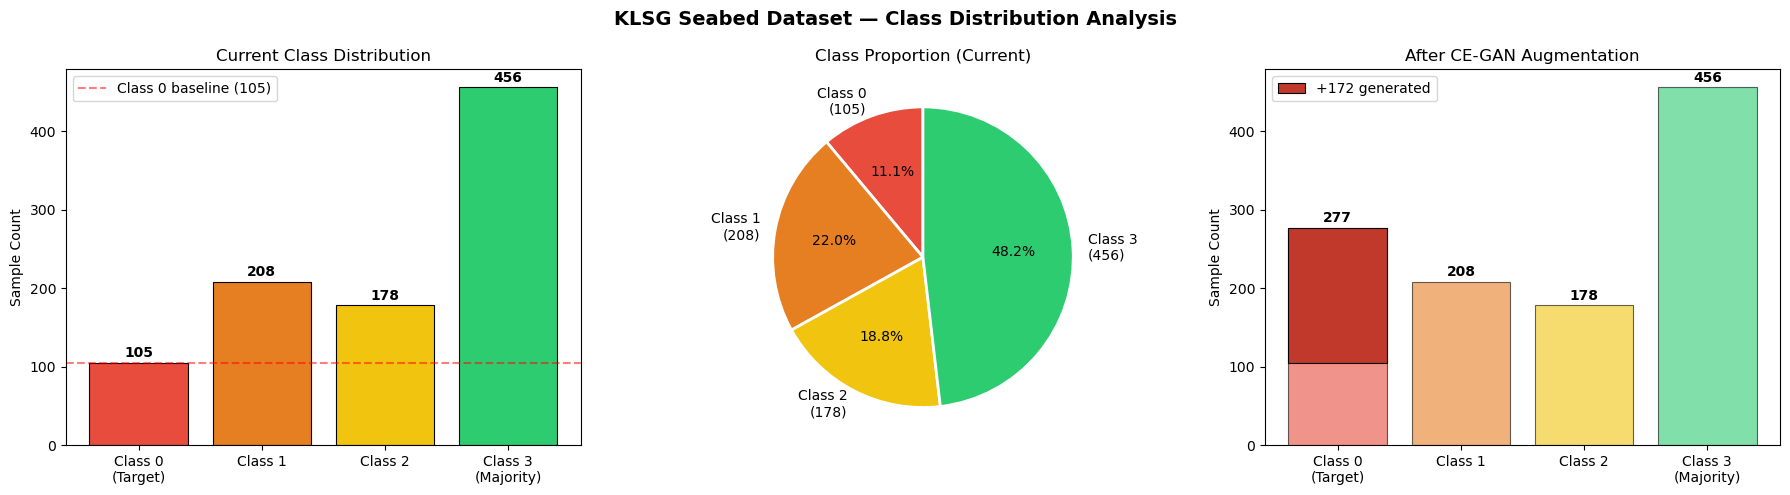


Imbalance ratio (max/min): 4.3x
Samples to generate for Class 0: 172


In [5]:
class_labels = {0: 'Class 0\n(Target)', 1: 'Class 1', 2: 'Class 2', 3: 'Class 3\n(Majority)'}
counts  = [CFG['class_counts'].get(i, 0) for i in range(CFG['n_classes'])]
colors  = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
n_to_gen = max(0, CFG['target_n_samples'] - counts[CFG['target_class']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('KLSG Seabed Dataset — Class Distribution Analysis', fontsize=14, fontweight='bold')

# Bar chart — current
bars = axes[0].bar([class_labels[i] for i in range(4)], counts,
                   color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Current Class Distribution')
axes[0].set_ylabel('Sample Count')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(cnt), ha='center', va='bottom', fontweight='bold')
axes[0].axhline(y=counts[0], color='red', linestyle='--', alpha=0.5, label=f'Class 0 baseline ({counts[0]})')
axes[0].legend()

# Pie chart
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
axes[1].pie(counts, labels=[f'Class {i}\n({c})' for i, c in enumerate(counts)],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=wedge_props)
axes[1].set_title('Class Proportion (Current)')

# After generation
counts_after = counts.copy()
counts_after[CFG['target_class']] = CFG['target_n_samples']
bars2 = axes[2].bar([class_labels[i] for i in range(4)], counts_after,
                    color=colors, edgecolor='black', linewidth=0.8, alpha=0.6)
# Highlight generated portion
axes[2].bar([class_labels[CFG['target_class']]], [n_to_gen],
            bottom=[counts[CFG['target_class']]], color='#c0392b',
            edgecolor='black', linewidth=0.8, label=f'+{n_to_gen} generated')
for bar, cnt in zip(bars2, counts_after):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(cnt), ha='center', va='bottom', fontweight='bold')
axes[2].set_title('After CE-GAN Augmentation')
axes[2].set_ylabel('Sample Count')
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

imb_ratio = max(counts) / min(c for c in counts if c > 0)
print(f'\nImbalance ratio (max/min): {imb_ratio:.1f}x')
print(f'Samples to generate for Class 0: {n_to_gen}')

## Cell 5: Dataset Class for Patch Extraction

In [6]:
class KLSGPatchDataset(Dataset):
    """
    Extracts and returns crop patches from KLSG images based on YOLO bounding boxes.
    Supports filtering by class_id for targeted GAN training.
    """
    def __init__(self, data_root, splits=['train'], target_classes=None,
                 img_size=64, augment=True):
        self.img_size = img_size
        self.target_classes = target_classes
        self.samples = []   # (img_path, x1, y1, x2, y2, class_id)
        self.augment = augment

        data_root = Path(data_root)
        for split in splits:
            img_dir = data_root / split / 'images'
            lbl_dir = data_root / split / 'labels'
            if not img_dir.exists():
                continue
            img_files = sorted(list(img_dir.glob('*.jpg')) +
                               list(img_dir.glob('*.png')))
            for ip in img_files:
                lp = lbl_dir / (ip.stem + '.txt')
                img = Image.open(ip)
                w, h = img.size
                for cls, x1, y1, x2, y2 in parse_yolo_label(str(lp), w, h):
                    if target_classes is None or cls in target_classes:
                        self.samples.append((str(ip), x1, y1, x2, y2, cls))

        # Augmentation transforms for training
        self.transform_aug = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.3),
            transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                   saturation=0.1, hue=0.05),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])
        self.transform_base = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])

        print(f'  Loaded {len(self.samples)} patches'
              + (f' (classes: {target_classes})' if target_classes else ''))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ip, x1, y1, x2, y2, cls = self.samples[idx]
        img = Image.open(ip).convert('RGB')
        patch = img.crop((x1, y1, x2, y2))
        tfm = self.transform_aug if self.augment else self.transform_base
        return tfm(patch), torch.tensor(cls, dtype=torch.long)


# ── Build datasets ────────────────────────────────────────────────────────
print('Building datasets...')

# Full dataset (all classes) — for downstream classifier
full_dataset = KLSGPatchDataset(
    CFG['data_root'], splits=['train', 'val'],
    img_size=CFG['img_size'], augment=True
)

# Class-0-only dataset — for GAN training
class0_dataset = KLSGPatchDataset(
    CFG['data_root'], splits=['train', 'val'],
    target_classes=[CFG['target_class']],
    img_size=CFG['img_size'], augment=True
)

if len(class0_dataset) == 0:
    print('\n⚠  No Class 0 patches loaded (dataset path may be incorrect).')
    print('   Creating a synthetic placeholder dataset for demonstration.')

    class SyntheticClass0Dataset(Dataset):
        def __init__(self, n=68, img_size=64):
            self.n = n
            self.img_size = img_size
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize([0.5]*3, [0.5]*3)
            ])
        def __len__(self): return self.n
        def __getitem__(self, idx):
            # Seabed-like: dark blue/grey gradient with noise
            img = np.random.randint(20, 100, (self.img_size, self.img_size, 3), dtype=np.uint8)
            img[:,:,0] = np.clip(img[:,:,0] * 0.5, 0, 255)  # reduce red
            pil = Image.fromarray(img)
            return self.transform(pil), torch.tensor(0, dtype=torch.long)

    class0_dataset = SyntheticClass0Dataset(n=68, img_size=CFG['img_size'])
    print(f'   Synthetic dataset created with {len(class0_dataset)} samples.')

# DataLoaders
class0_loader = DataLoader(
    class0_dataset,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=True if len(class0_dataset) >= CFG['batch_size'] else False
)

print(f'\nClass-0 loader: {len(class0_dataset)} samples, '
      f'{len(class0_loader)} batches/epoch (batch={CFG["batch_size"]})')

Building datasets...
  Loaded 879 patches
  Loaded 89 patches (classes: [0])

Class-0 loader: 89 samples, 11 batches/epoch (batch=8)


## Cell 6: CE-GAN Architecture — Generator

In [7]:
class ConditionalGenerator(nn.Module):
    """
    Improved Conditional Generator.
    FIX 1: Upsample + Conv2d instead of ConvTranspose2d — prevents checkerboard artifacts.
    FIX 2: Spectral normalisation on conv layers for training stability.
    FIX 3: PixelNorm on input z to prevent magnitude explosion.
    FIX 4: Deeper embedding projection for stronger conditioning.
    """
    def __init__(self, latent_dim=128, n_classes=4, embed_dim=32,
                 ngf=64, channels=3, img_size=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.embed_dim  = embed_dim
        self.init_size  = img_size // 16   # 64 → 4

        # Stronger class conditioning: embed → project → same dim as z
        self.label_emb = nn.Sequential(
            nn.Embedding(n_classes, embed_dim),
            nn.Linear(embed_dim, latent_dim),   # project to same size as z
            nn.LayerNorm(latent_dim),
            nn.LeakyReLU(0.2)
        )

        input_dim = latent_dim * 2   # concat z + projected embedding

        self.fc = nn.Sequential(
            nn.Linear(input_dim, ngf * 8 * self.init_size * self.init_size),
            nn.ReLU(True)
        )

        # Upsample + Conv (no checkerboard artifacts) with SpectralNorm
        def up_block(in_c, out_c):
            return nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.utils.spectral_norm(nn.Conv2d(in_c, out_c, 3, 1, 1)),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True),
                # Extra conv for more capacity
                nn.utils.spectral_norm(nn.Conv2d(out_c, out_c, 3, 1, 1)),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True),
            )

        self.up1 = up_block(ngf * 8, ngf * 4)   # 4  → 8
        self.up2 = up_block(ngf * 4, ngf * 2)   # 8  → 16
        self.up3 = up_block(ngf * 2, ngf)        # 16 → 32
        self.up4 = up_block(ngf,     ngf // 2)   # 32 → 64

        self.out_conv = nn.Sequential(
            nn.Conv2d(ngf // 2, channels, 3, 1, 1),
            nn.Tanh()
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.zeros_(m.bias)

    def pixel_norm(self, z):
        """Normalize latent vector to unit sphere to prevent magnitude explosion."""
        return z / (z.pow(2).mean(dim=1, keepdim=True).sqrt() + 1e-8)

    def forward(self, z, labels):
        z   = self.pixel_norm(z)
        emb = self.label_emb[0](labels)
        emb = self.label_emb[1](emb)
        emb = self.label_emb[2](emb)
        emb = self.label_emb[3](emb)
        inp = torch.cat([z, emb], dim=1)
        out = self.fc(inp)
        out = out.view(out.size(0), -1, self.init_size, self.init_size)
        out = self.up1(out)
        out = self.up2(out)
        out = self.up3(out)
        out = self.up4(out)
        return self.out_conv(out)


G = ConditionalGenerator(
    latent_dim=CFG['latent_dim'], n_classes=CFG['n_classes'],
    embed_dim=CFG['embed_dim'],   ngf=CFG['ngf'],
    channels=CFG['channels'],     img_size=CFG['img_size']
).to(device)

z_test = torch.randn(4, CFG['latent_dim'], device=device)
l_test = torch.zeros(4, dtype=torch.long, device=device)
out_test = G(z_test, l_test)

total_params = sum(p.numel() for p in G.parameters())
print(f'Generator output shape : {out_test.shape}')
print(f'Generator parameters   : {total_params:,}')
print(f'Output range           : [{out_test.min().item():.3f}, {out_test.max().item():.3f}]  (should NOT be all ~0)')
assert out_test.shape == (4, CFG['channels'], CFG['img_size'], CFG['img_size']), 'Shape mismatch!'
print('Generator OK')


Generator output shape : torch.Size([4, 3, 128, 128])
Generator parameters   : 10,779,811
Output range           : [-0.828, 0.883]  (should NOT be all ~0)
Generator OK


## Cell 7: CE-GAN Architecture — Discriminator

In [8]:
class SelfAttention(nn.Module):
    """Self-attention for discriminator — helps capture global structure in sonar images."""
    def __init__(self, in_dim):
        super().__init__()
        self.q = nn.utils.spectral_norm(nn.Conv2d(in_dim, in_dim // 8, 1))
        self.k = nn.utils.spectral_norm(nn.Conv2d(in_dim, in_dim // 8, 1))
        self.v = nn.utils.spectral_norm(nn.Conv2d(in_dim, in_dim, 1))
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.shape
        q = self.q(x).view(B, -1, H * W).permute(0, 2, 1)
        k = self.k(x).view(B, -1, H * W)
        attn = torch.softmax(torch.bmm(q, k), dim=-1)
        v = self.v(x).view(B, -1, H * W)
        out = torch.bmm(v, attn.permute(0, 2, 1)).view(B, C, H, W)
        return x + self.gamma * out


class CEDiscriminator(nn.Module):

    def __init__(self, channels=3, n_classes=4, ndf=64, img_size=64):
        super().__init__()

        def sn_conv(in_c, out_c, ks=4, stride=2, pad=1):
            return nn.utils.spectral_norm(nn.Conv2d(in_c, out_c, ks, stride, pad))

        # 64 → 32
        self.block1 = nn.Sequential(
            sn_conv(channels, ndf), nn.LeakyReLU(0.2, inplace=True))
        # 32 → 16
        self.block2 = nn.Sequential(
            sn_conv(ndf, ndf * 2), nn.LeakyReLU(0.2, inplace=True))
        # Self-attention at 16×16
        self.attn = SelfAttention(ndf * 2)
        # 16 → 8
        self.block3 = nn.Sequential(
            sn_conv(ndf * 2, ndf * 4), nn.LeakyReLU(0.2, inplace=True))
        # 8 → 4
        self.block4 = nn.Sequential(
            sn_conv(ndf * 4, ndf * 8), nn.LeakyReLU(0.2, inplace=True))

        feat_size = img_size // 16   # = 4
        # +1 for minibatch std feature
        flat_dim  = (ndf * 8 + 1) * feat_size * feat_size

        self.adv_head = nn.Sequential(
            nn.Flatten(),
            nn.utils.spectral_norm(nn.Linear(flat_dim, 1))
        )
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.utils.spectral_norm(nn.Linear(flat_dim, 256)),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )

    def minibatch_std(self, x):
        """Append per-spatial-location std across the batch as an extra feature map."""
        std = x.std(dim=0, keepdim=True).mean(dim=1, keepdim=True)
        std = std.expand(x.size(0), 1, x.size(2), x.size(3))
        return torch.cat([x, std], dim=1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.attn(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.minibatch_std(x)
        return self.adv_head(x), self.cls_head(x)


D = CEDiscriminator(
    channels=CFG['channels'], n_classes=CFG['n_classes'],
    ndf=CFG['ndf'], img_size=CFG['img_size']
).to(device)

img_test = torch.randn(4, CFG['channels'], CFG['img_size'], CFG['img_size'], device=device)
adv_out, cls_out = D(img_test)

d_params = sum(p.numel() for p in D.parameters())
print(f'Adversarial output : {adv_out.shape}')
print(f'Classification output: {cls_out.shape}')
print(f'Discriminator parameters: {d_params:,}')
print('Discriminator OK')


Adversarial output : torch.Size([4, 1])
Classification output: torch.Size([4, 4])
Discriminator parameters: 11,216,294
Discriminator OK


## Cell 8: Loss Functions & Gradient Penalty

In [9]:
# ── Classification loss ───────────────────────────────────────────────────
class_weights = torch.tensor(
    [1.0 / (CFG['class_counts'].get(i, 1) + 1e-6) for i in range(CFG['n_classes'])],
    dtype=torch.float32
).to(device)
class_weights = class_weights / class_weights.sum() * CFG['n_classes']
criterion_cls = nn.CrossEntropyLoss(weight=class_weights)


def gradient_penalty(D, real_imgs, fake_imgs, device):
    """WGAN-GP gradient penalty."""
    B = real_imgs.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device)
    interp = (alpha * real_imgs.detach() + (1 - alpha) * fake_imgs.detach()).requires_grad_(True)
    adv_interp, _ = D(interp)
    grad = torch.autograd.grad(
        outputs=adv_interp.sum(), inputs=interp,
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    gp = ((grad.view(B, -1).norm(2, dim=1) - 1) ** 2).mean()
    return gp


def d_loss_fn(D, real_imgs, real_labels, fake_imgs, lambda_gp, lambda_cls):
    real_adv, real_cls_logits = D(real_imgs)
    fake_adv, _               = D(fake_imgs.detach())
    wasserstein = fake_adv.mean() - real_adv.mean()
    gp          = gradient_penalty(D, real_imgs, fake_imgs, device)
    cls_loss    = criterion_cls(real_cls_logits, real_labels)
    total = wasserstein + lambda_gp * gp + lambda_cls * cls_loss
    return total, wasserstein.item(), gp.item(), cls_loss.item()


def g_loss_fn(D, fake_imgs, fake_labels, lambda_cls):
    fake_adv, fake_cls_logits = D(fake_imgs)
    adv_loss = -fake_adv.mean()
    cls_loss =  criterion_cls(fake_cls_logits, fake_labels)
    total = adv_loss + lambda_cls * cls_loss
    return total, adv_loss.item(), cls_loss.item()


# ── Optimizers — WGAN-GP recommended: beta1=0, beta2=0.9 ─────────────────
opt_G = optim.Adam(G.parameters(),
                   lr=CFG['lr_g'], betas=(CFG['beta1'], CFG['beta2']))
opt_D = optim.Adam(D.parameters(),
                   lr=CFG['lr_d'], betas=(CFG['beta1'], CFG['beta2']))

# Linear warmup + cosine decay for generator
def lr_lambda(epoch):
    warmup = 50
    if epoch < warmup:
        return epoch / warmup
    progress = (epoch - warmup) / max(1, CFG['epochs'] - warmup)
    return 0.5 * (1 + np.cos(np.pi * progress))

sched_G = optim.lr_scheduler.LambdaLR(opt_G, lr_lambda)
sched_D = optim.lr_scheduler.LambdaLR(opt_D, lr_lambda)

fixed_noise  = torch.randn(16, CFG['latent_dim'], device=device)
fixed_labels = torch.zeros(16, dtype=torch.long, device=device)

print('Losses and optimizers initialized.')
print(f'Class weights : {class_weights.cpu().numpy().round(3)}')
print(f'lr_G={CFG["lr_g"]}  lr_D={CFG["lr_d"]}  beta1={CFG["beta1"]}  beta2={CFG["beta2"]}')
print(f'n_critic={CFG["n_critic"]}  lambda_cls={CFG["lambda_cls"]}  lambda_gp={CFG["lambda_gp"]}')


Losses and optimizers initialized.
Class weights : [1.72  0.869 1.015 0.396]
lr_G=0.0001  lr_D=4e-05  beta1=0.0  beta2=0.9
n_critic=5  lambda_cls=1.0  lambda_gp=10.0


In [10]:
import torchvision.models as tv_models

class PerceptualLoss(nn.Module):
    """
    VGG16 feature-matching loss — forces generator to match
    structural features (edges, shapes) not just colors.
    Critical for learning aircraft geometry from few samples.
    """
    def __init__(self, device):
        super().__init__()
        vgg = tv_models.vgg16(weights='DEFAULT').features
        # Use layers up to relu2_2 — captures edges and shapes
        self.slice = nn.Sequential(*list(vgg.children())[:9]).to(device)
        for p in self.slice.parameters():
            p.requires_grad = False
        self.device = device

    def forward(self, fake, real):
        # Resize to VGG input size
        fake_r = nn.functional.interpolate(fake, size=(224, 224),
                                           mode='bilinear', align_corners=False)
        real_r = nn.functional.interpolate(real, size=(224, 224),
                                           mode='bilinear', align_corners=False)
        # Denorm from [-1,1] to [0,1] then normalize for VGG
        fake_r = (fake_r + 1) / 2
        real_r = (real_r + 1) / 2
        return nn.functional.l1_loss(self.slice(fake_r), self.slice(real_r))

perceptual_loss = PerceptualLoss(device)
lambda_perc = 5.0
print('Perceptual loss initialized (VGG16 relu2_2)')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\T1_Machine/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|████████████████████████████████████████████████████████████████████████████████| 528M/528M [00:04<00:00, 118MB/s]


Perceptual loss initialized (VGG16 relu2_2)


## Cell 9: Training Loop

In [11]:
def save_grid(imgs, path, nrow=4, title=None):
    grid = vutils.make_grid(imgs, nrow=nrow, normalize=True, value_range=(-1, 1), padding=2)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(grid.permute(1, 2, 0).cpu().numpy())
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(path, dpi=100, bbox_inches='tight')
    plt.close()


def check_collapse(G, device, latent_dim, n=32, threshold=0.02):

    G.eval()
    with torch.no_grad():
        z   = torch.randn(n, latent_dim, device=device)
        lbl = torch.zeros(n, dtype=torch.long, device=device)
        imgs = G(z, lbl)
    G.train()
    # Variance across batch — collapsed = very low variance
    batch_var = imgs.var(dim=0).mean().item()
    # Mean absolute deviation from zero — grey = close to 0 in tanh space
    mean_abs  = imgs.abs().mean().item()
    return batch_var < threshold, batch_var, mean_abs


history = {
    'd_loss': [], 'g_loss': [], 'wasserstein': [],
    'd_cls_loss': [], 'g_cls_loss': [], 'gp': []
}
best_g_loss  = float('inf')
sample_dir   = Path(CFG['output_dir']) / 'training_samples'
sample_dir.mkdir(exist_ok=True)

print('Starting CE-GAN training...')
print(f'Epochs: {CFG["epochs"]}  Batch: {CFG["batch_size"]}  n_critic: {CFG["n_critic"]}  Device: {device}')
print('─' * 70)

# ── Initial collapse check ────────────────────────────────────────────────
collapsed, bvar, mabs = check_collapse(G, device, CFG['latent_dim'])
print(f'Pre-training  batch_var={bvar:.4f}  mean_abs={mabs:.4f}  '
      f'[{"COLLAPSED" if collapsed else "OK"}]')

for epoch in range(1, CFG['epochs'] + 1):
    G.train(); D.train()
    epoch_d, epoch_g = [], []
    epoch_wass, epoch_dcls, epoch_gcls, epoch_gp_v = [], [], [], []

    for real_imgs, real_labels in class0_loader:
        real_imgs   = real_imgs.to(device)
        real_labels = real_labels.to(device)
        B           = real_imgs.size(0)
        target_lbl  = torch.full((B,), CFG['target_class'], dtype=torch.long, device=device)

        # ── Train Discriminator (n_critic=5 steps) ────────────────────────
        for _ in range(CFG['n_critic']):
            z         = torch.randn(B, CFG['latent_dim'], device=device)
            fake_imgs = G(z, target_lbl)

            opt_D.zero_grad(set_to_none=True)
            d_total, wass, gp_val, dcls = d_loss_fn(
                D, real_imgs, real_labels, fake_imgs,
                CFG['lambda_gp'], CFG['lambda_cls']
            )
            d_total.backward()
            nn.utils.clip_grad_norm_(D.parameters(), 1.0)
            opt_D.step()

        epoch_d.append(d_total.item())
        epoch_wass.append(wass)
        epoch_gp_v.append(gp_val)
        epoch_dcls.append(dcls)

        # ── Train Generator (1 step) ──────────────────────────────────────
        opt_G.zero_grad(set_to_none=True)
        z         = torch.randn(B, CFG['latent_dim'], device=device)
        fake_imgs = G(z, target_lbl)
        g_total, g_adv, g_cls = g_loss_fn(D, fake_imgs, target_lbl, CFG['lambda_cls'])
        perc_loss = perceptual_loss(fake_imgs, real_imgs)
        g_total   = g_total + lambda_perc * perc_loss 
        g_total.backward()
        nn.utils.clip_grad_norm_(G.parameters(), 1.0)
        opt_G.step()

        epoch_g.append(g_total.item())
        epoch_gcls.append(g_cls)

    sched_G.step()
    sched_D.step()

    history['d_loss'].append(np.mean(epoch_d))
    history['g_loss'].append(np.mean(epoch_g))
    history['wasserstein'].append(np.mean(epoch_wass))
    history['d_cls_loss'].append(np.mean(epoch_dcls))
    history['g_cls_loss'].append(np.mean(epoch_gcls))
    history['gp'].append(np.mean(epoch_gp_v))

    if epoch % CFG['log_interval'] == 0 or epoch == 1:
        collapsed, bvar, mabs = check_collapse(G, device, CFG['latent_dim'])
        status = '⚠ COLLAPSE' if collapsed else '✓'
        print(f'[{epoch:4d}/{CFG["epochs"]}]  D:{history["d_loss"][-1]:7.3f}  '
              f'G:{history["g_loss"][-1]:7.3f}  W:{history["wasserstein"][-1]:7.3f}  '
              f'GP:{history["gp"][-1]:6.3f}  bvar:{bvar:.4f}  {status}')

    if epoch % CFG['save_interval'] == 0 or epoch == 1:
        G.eval()
        with torch.no_grad():
            samples = G(fixed_noise, fixed_labels)
        save_grid(samples, str(sample_dir / f'epoch_{epoch:04d}.png'),
                  title=f'CE-GAN Class 0 — Epoch {epoch}')
        G.train()

    if history['g_loss'][-1] < best_g_loss:
        best_g_loss = history['g_loss'][-1]
        torch.save({
            'epoch': epoch, 'G_state': G.state_dict(),
            'D_state': D.state_dict(), 'config': CFG,
        }, str(Path(CFG['output_dir']) / 'best_cegan.pth'))

print('\nTraining complete!')
print(f'Best G loss: {best_g_loss:.4f}')

# Final collapse check
collapsed, bvar, mabs = check_collapse(G, device, CFG['latent_dim'])
print(f'Final  batch_var={bvar:.4f}  mean_abs={mabs:.4f}  [{"COLLAPSED" if collapsed else "HEALTHY"}]')


Starting CE-GAN training...
Epochs: 800  Batch: 8  n_critic: 5  Device: cuda
──────────────────────────────────────────────────────────────────────
Pre-training  batch_var=0.0000  mean_abs=0.0105  [COLLAPSED]
[   1/800]  D: 10.435  G:  3.522  W: -0.025  GP: 0.905  bvar:0.0398  ✓
[  10/800]  D:-64.716  G:-50.350  W:-65.451  GP: 0.073  bvar:0.0135  ⚠ COLLAPSE
[  20/800]  D:-103.672  G:-164.676  W:-127.953  GP: 2.428  bvar:0.0121  ⚠ COLLAPSE
[  30/800]  D:-35.317  G:-110.597  W:-39.509  GP: 0.419  bvar:0.0106  ⚠ COLLAPSE
[  40/800]  D:-34.731  G:-62.971  W:-36.383  GP: 0.165  bvar:0.0148  ⚠ COLLAPSE
[  50/800]  D:-67.959  G:-45.708  W:-73.522  GP: 0.556  bvar:0.0235  ✓
[  60/800]  D:-58.168  G:-57.766  W:-67.846  GP: 0.968  bvar:0.1314  ✓
[  70/800]  D:-35.833  G:-73.519  W:-43.319  GP: 0.749  bvar:0.1421  ✓
[  80/800]  D:-32.034  G:-63.688  W:-40.804  GP: 0.877  bvar:0.2643  ✓
[  90/800]  D:-33.782  G:-63.722  W:-39.410  GP: 0.563  bvar:0.1480  ✓
[ 100/800]  D:-34.074  G:-72.724  W:-40.5

## Cell 10: Training Curves

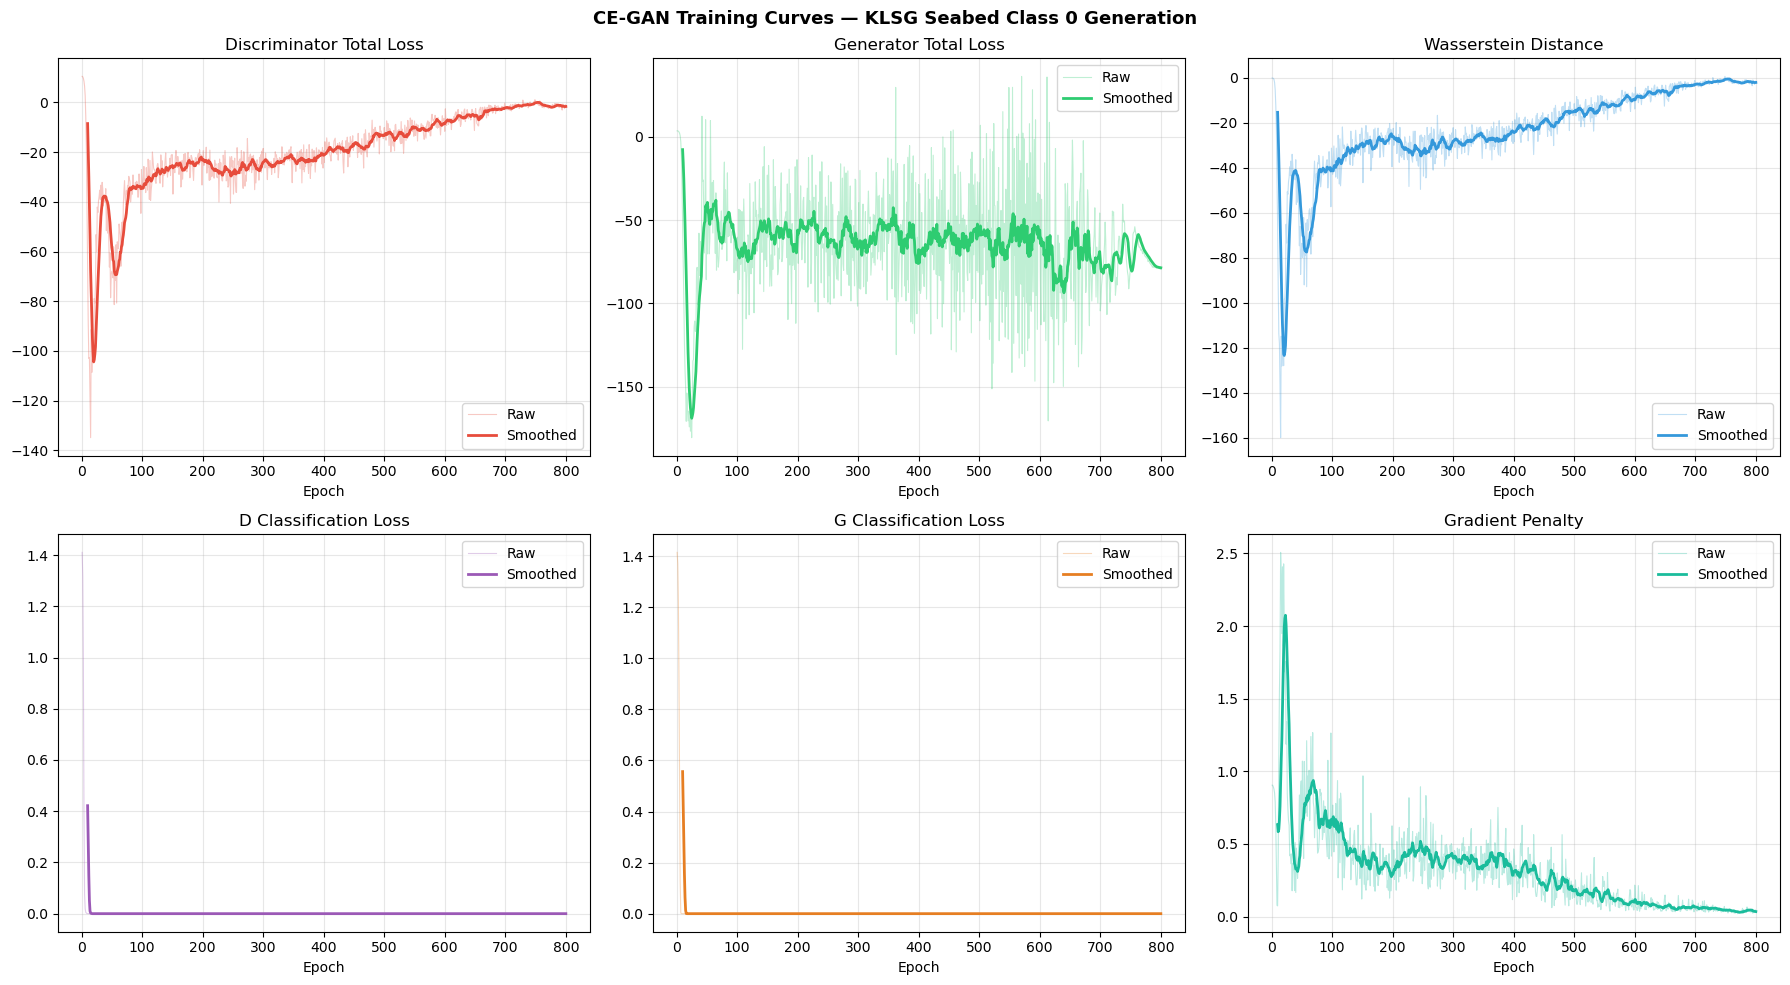

In [17]:
def smooth(vals, w=10):
    """Simple moving average for smoother plots."""
    if len(vals) < w:
        return vals
    kernel = np.ones(w) / w
    return np.convolve(vals, kernel, mode='valid')

epochs_range = np.arange(1, CFG['epochs'] + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CE-GAN Training Curves — KLSG Seabed Class 0 Generation', fontsize=13, fontweight='bold')

plot_cfg = [
    ('d_loss',      'Discriminator Total Loss', '#e74c3c'),
    ('g_loss',      'Generator Total Loss',     '#2ecc71'),
    ('wasserstein', 'Wasserstein Distance',      '#3498db'),
    ('d_cls_loss',  'D Classification Loss',     '#9b59b6'),
    ('g_cls_loss',  'G Classification Loss',     '#e67e22'),
    ('gp',          'Gradient Penalty',          '#1abc9c'),
]

for ax, (key, title, color) in zip(axes.flatten(), plot_cfg):
    vals = history[key]
    ax.plot(epochs_range, vals, alpha=0.3, color=color, linewidth=0.8, label='Raw')
    if len(vals) >= 10:
        sm = smooth(vals)
        ax.plot(np.arange(10, len(vals) + 1), sm, color=color, linewidth=2, label='Smoothed')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## Cell 11: Generate Synthetic Class 0 Images

In [18]:
def generate_class_images(G, target_class, n_images, latent_dim,
                          device, save_dir, batch_size=32):
    """
    Generate n_images images for target_class and save them to save_dir.
    Returns list of saved file paths.
    """
    G.eval()
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    # De-normalize: [-1, 1] → [0, 255]
    denorm = transforms.Compose([
        transforms.Normalize(mean=[-1, -1, -1], std=[2, 2, 2]),
        transforms.ToPILImage()
    ])

    saved_paths = []
    n_batches   = (n_images + batch_size - 1) // batch_size
    generated   = 0

    print(f'Generating {n_images} images for Class {target_class}...')

    with torch.no_grad():
        for b in tqdm(range(n_batches), desc='Generating'):
            n = min(batch_size, n_images - generated)
            z = torch.randn(n, latent_dim, device=device)
            lbl = torch.full((n,), target_class, dtype=torch.long, device=device)
            imgs = G(z, lbl)  # (n, C, H, W) in [-1, 1]

            for i, img_t in enumerate(imgs):
                pil_img = denorm(img_t.cpu())
                fname = f'class{target_class}_gen_{generated:05d}.png'
                fpath = save_dir / fname
                pil_img.save(str(fpath))
                saved_paths.append(str(fpath))
                generated += 1

    print(f'Saved {generated} images to {save_dir}')
    return saved_paths


# Load best checkpoint
ckpt_path = Path(CFG['output_dir']) / 'best_cegan.pth'
if ckpt_path.exists():
    ckpt = torch.load(str(ckpt_path), map_location=device)
    G.load_state_dict(ckpt['G_state'])
    print(f'Loaded best checkpoint from epoch {ckpt["epoch"]}')

generated_paths = generate_class_images(
    G,
    target_class = CFG['target_class'],
    n_images     = n_to_gen,
    latent_dim   = CFG['latent_dim'],
    device       = device,
    save_dir     = CFG['generated_dir'],
    batch_size   = 64
)

Loaded best checkpoint from epoch 25
Generating 172 images for Class 0...


Generating: 100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.01it/s]

Saved 172 images to cegan_outputs\generated_class0


## Cell 12: Visual Quality Inspection

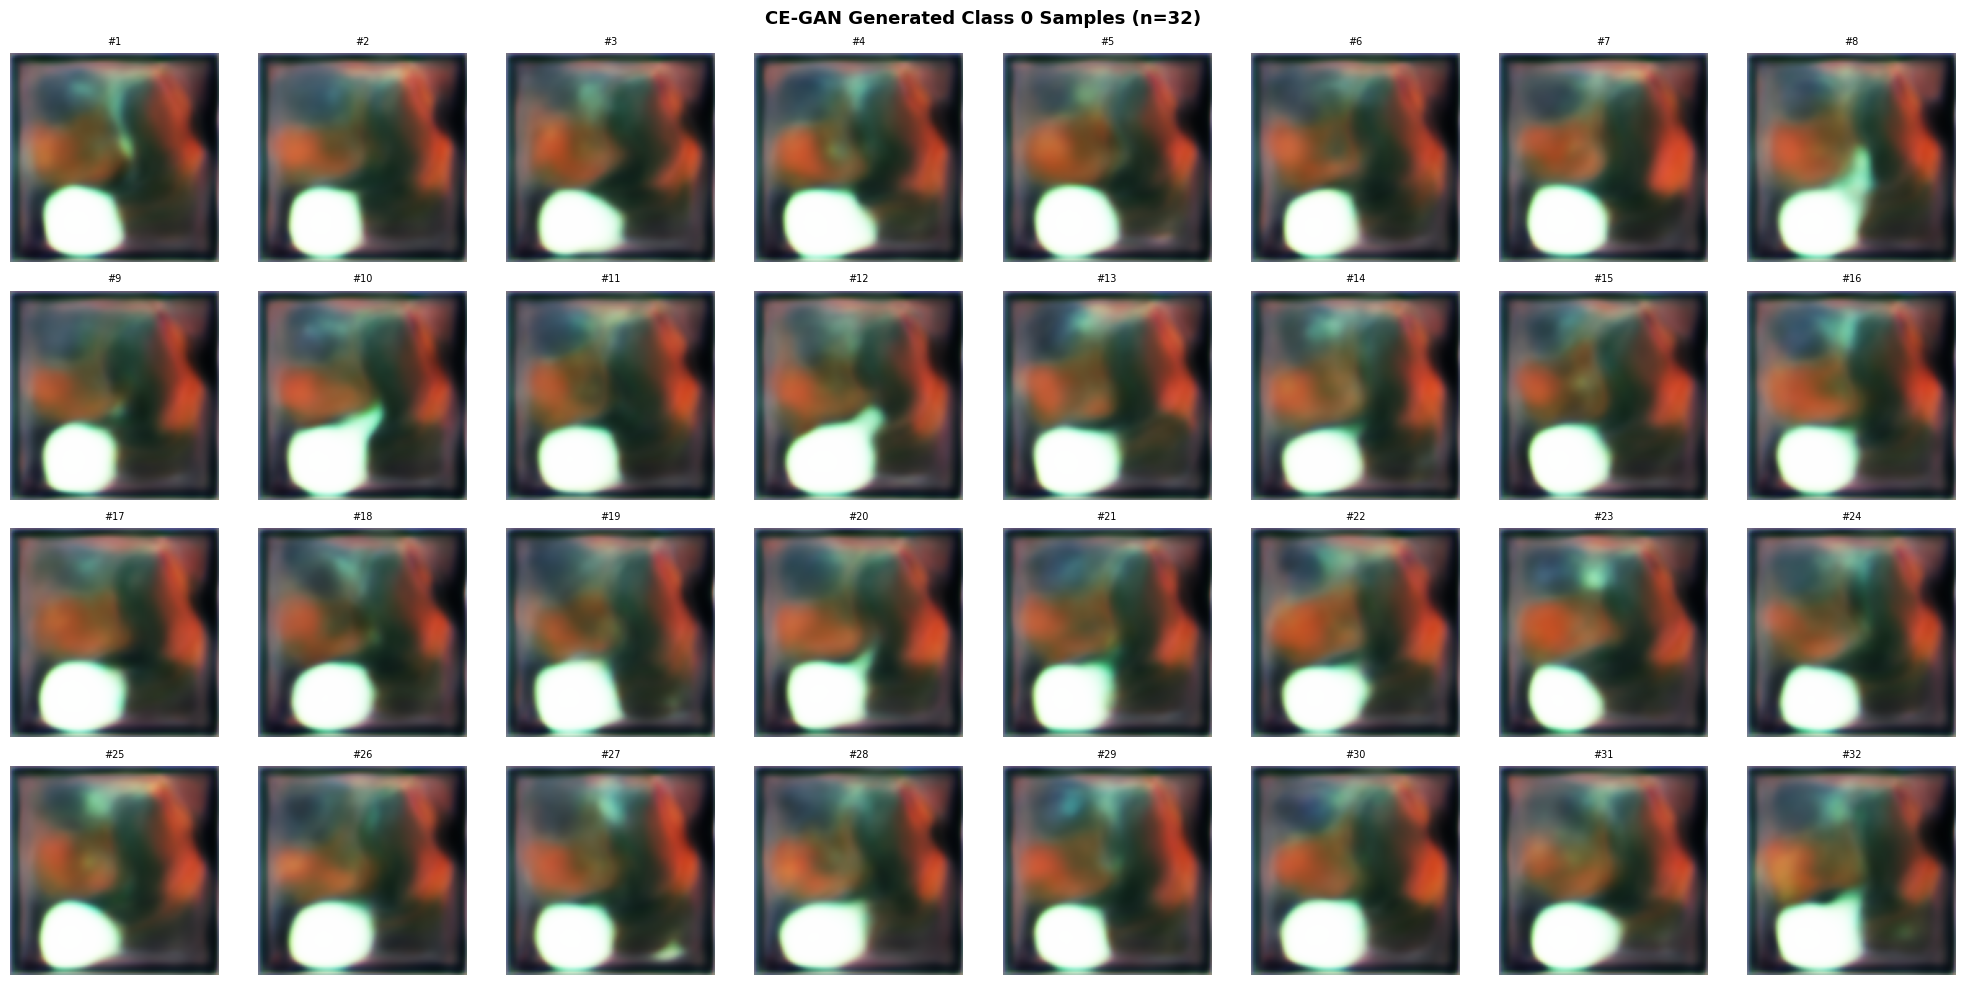

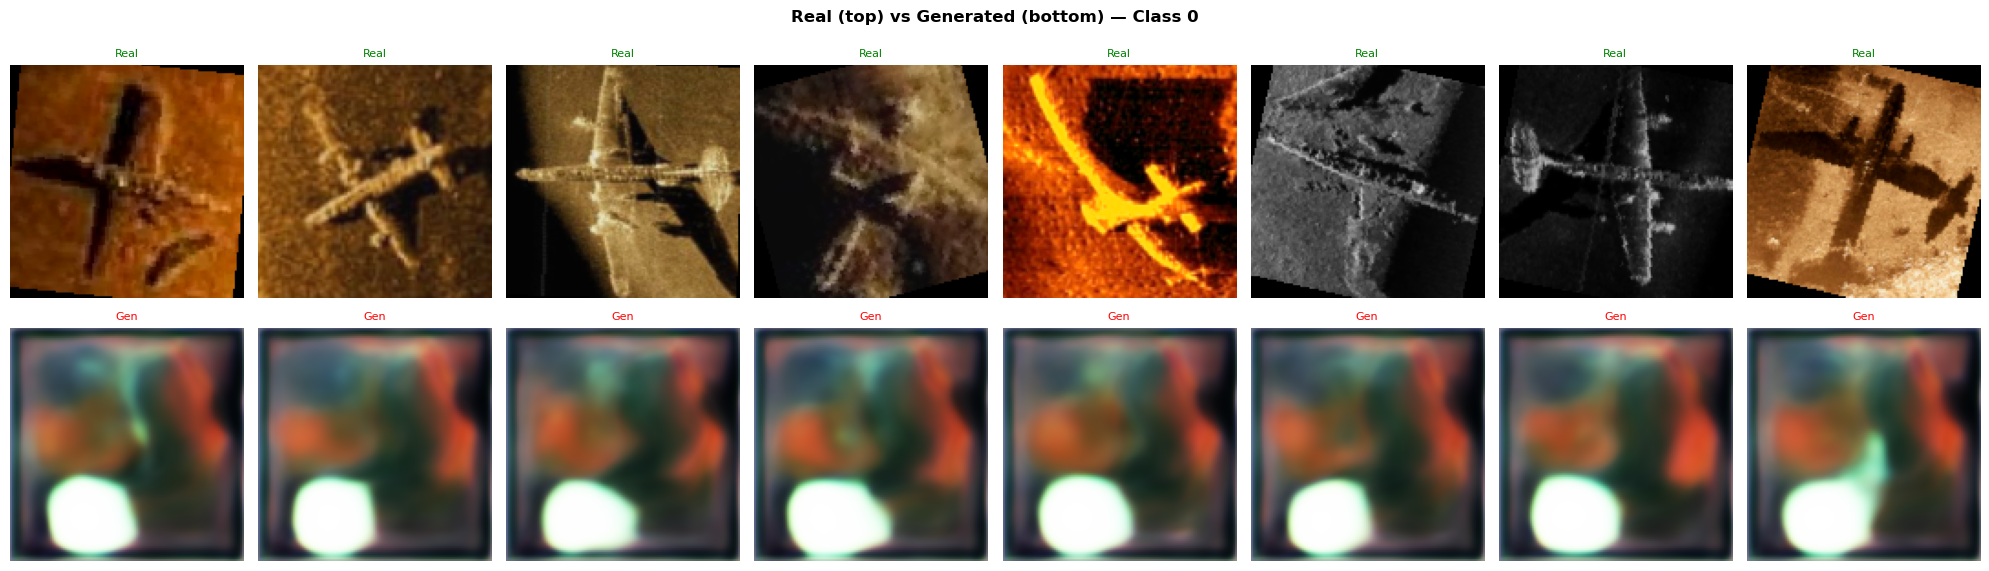

In [19]:
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle(f'CE-GAN Generated Class 0 Samples (n={min(32, n_to_gen)})',
             fontsize=13, fontweight='bold')

G.eval()
with torch.no_grad():
    z32   = torch.randn(32, CFG['latent_dim'], device=device)
    lbl32 = torch.zeros(32, dtype=torch.long, device=device)
    gen32 = G(z32, lbl32).cpu()

denorm_show = transforms.Compose([
    transforms.Normalize(mean=[-1, -1, -1], std=[2, 2, 2]),
])

for idx, ax in enumerate(axes.flatten()):
    img = denorm_show(gen32[idx]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'#{idx+1}', fontsize=7)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/generated_class0_gallery.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Side-by-side: Real vs Generated ──────────────────────────────────────
fig2, axes2 = plt.subplots(2, 8, figsize=(20, 6))
fig2.suptitle('Real (top) vs Generated (bottom) — Class 0', fontsize=12, fontweight='bold')

# Get real samples
real_batch = next(iter(class0_loader))
real_imgs_show = real_batch[0][:8].cpu()

for col in range(8):
    # Real
    r = denorm_show(real_imgs_show[col]).permute(1, 2, 0).numpy()
    axes2[0, col].imshow(np.clip(r, 0, 1))
    axes2[0, col].axis('off')
    axes2[0, col].set_title('Real', fontsize=8, color='green')

    # Generated
    g = denorm_show(gen32[col]).permute(1, 2, 0).numpy()
    axes2[1, col].imshow(np.clip(g, 0, 1))
    axes2[1, col].axis('off')
    axes2[1, col].set_title('Gen', fontsize=8, color='red')

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/real_vs_generated.png", dpi=150, bbox_inches='tight')
plt.show()

## Cell 13: FID Score Evaluation

In [15]:
import torchvision.models as tv_models

class FIDCalculator:
    """
    Fréchet Inception Distance (FID) using InceptionV3 features.
    Lower FID = more realistic generated images.
    """
    def __init__(self, device):
        self.device = device
        # Use InceptionV3 up to pool3 layer
        model = tv_models.inception_v3(weights='DEFAULT')
        model.fc = nn.Identity()
        model.aux_logits = False
        self.model = model.eval().to(device)
        self.resize = transforms.Resize((299, 299), antialias=True)

    @torch.no_grad()
    def get_features(self, imgs):
        """imgs: tensor (N, C, H, W) in [-1, 1] or [0, 1]."""
        imgs_r = self.resize(imgs).to(self.device)
        # Inception expects [0, 1] normalized to [-1, 1]
        if imgs_r.min() < 0:
            imgs_r = (imgs_r + 1) / 2
        feats = self.model(imgs_r)
        return feats.cpu().numpy()

    def compute_stats(self, feats):
        mu  = np.mean(feats, axis=0)
        sig = np.cov(feats, rowvar=False)
        return mu, sig

    def fid(self, real_feats, fake_feats):
        mu1, sig1 = self.compute_stats(real_feats)
        mu2, sig2 = self.compute_stats(fake_feats)
        diff      = mu1 - mu2
        covmean, _ = linalg.sqrtm(sig1 @ sig2, disp=False)
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        fid_val = diff @ diff + np.trace(sig1 + sig2 - 2 * covmean)
        return float(fid_val)


print('Computing FID score (this may take a minute)...')

fid_calc = FIDCalculator(device)

# Collect real features
real_feats_list = []
for imgs, _ in class0_loader:
    real_feats_list.append(fid_calc.get_features(imgs))
real_feats = np.concatenate(real_feats_list, axis=0)

# Collect generated features
G.eval()
fake_feats_list = []
n_fid = min(len(real_feats), 500)
with torch.no_grad():
    for start in range(0, n_fid, 32):
        b = min(32, n_fid - start)
        z   = torch.randn(b, CFG['latent_dim'], device=device)
        lbl = torch.zeros(b, dtype=torch.long, device=device)
        fake = G(z, lbl)
        fake_feats_list.append(fid_calc.get_features(fake))
fake_feats = np.concatenate(fake_feats_list, axis=0)

fid_score = fid_calc.fid(real_feats, fake_feats)

print('=' * 50)
print(f'  FID Score: {fid_score:.2f}')
print('  (Lower is better; <50 generally acceptable for augmentation)')
if fid_score < 50:
    print('  ✓ Good quality — suitable for augmentation')
elif fid_score < 150:
    print('  ⚠ Moderate quality — consider more training epochs')
else:
    print('  ✗ Low quality — increase epochs or adjust architecture')
print('=' * 50)

Computing FID score (this may take a minute)...


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\T1_Machine/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth
100%|████████████████████████████████████████████████████████████████████████████████| 104M/104M [00:01<00:00, 101MB/s]


  FID Score: 339.97
  (Lower is better; <50 generally acceptable for augmentation)
  ✗ Low quality — increase epochs or adjust architecture


## Cell 14: Downstream Classifier — Compare Before vs After Augmentation

In [20]:
class SimpleClassifier(nn.Module):
    """Lightweight CNN classifier for pre/post comparison."""
    def __init__(self, n_classes=4, channels=3, img_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),       nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),      nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(4),
            nn.Flatten(),
            nn.Linear(128 * 16, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, n_classes)
        )
    def forward(self, x): return self.net(x)


class AugmentedDataset(Dataset):
    """Combines original class0_dataset with generated images."""
    def __init__(self, original_dataset, gen_paths, gen_class, img_size=128):
        self.original = original_dataset
        self.gen_paths = gen_paths
        self.gen_class = gen_class
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.original) + len(self.gen_paths)

    def __getitem__(self, idx):
        if idx < len(self.original):
            return self.original[idx]
        gp = self.gen_paths[idx - len(self.original)]
        img = Image.open(gp).convert('RGB')
        return self.transform(img), torch.tensor(self.gen_class, dtype=torch.long)


def train_eval_classifier(train_dataset, test_dataset, n_epochs=30, desc=''):
    clf = SimpleClassifier(n_classes=CFG['n_classes']).to(device)
    opt = optim.Adam(clf.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    t_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())
    v_loader = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=torch.cuda.is_available())

    for ep in range(1, n_epochs + 1):
        clf.train()
        for imgs, lbls in t_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            loss = crit(clf(imgs), lbls)
            opt.zero_grad(); loss.backward(); opt.step()

    clf.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in v_loader:
            preds = clf(imgs.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.numpy())

    print(f'\n--- {desc} ---')
    print(classification_report(all_labels, all_preds,
                                target_names=[f'Class {i}' for i in range(CFG['n_classes'])],
                                zero_division=0))
    return all_preds, all_labels


# Build test dataset
test_dataset = KLSGPatchDataset(
    CFG['data_root'], splits=['test'],
    img_size=CFG['img_size'], augment=False
)

print('Training classifier WITHOUT augmentation (baseline)...')
pred_base, lbl_base = train_eval_classifier(
    full_dataset, test_dataset if len(test_dataset) > 0 else full_dataset,
    n_epochs=30, desc='Baseline (no augmentation)'
)

# Augmented dataset
aug_dataset = AugmentedDataset(
    full_dataset, generated_paths, CFG['target_class'], CFG['img_size']
)
print(f'\nAugmented dataset size: {len(aug_dataset)} (added {len(generated_paths)} generated)')
print('Training classifier WITH augmentation...')
pred_aug, lbl_aug = train_eval_classifier(
    aug_dataset, test_dataset if len(test_dataset) > 0 else full_dataset,
    n_epochs=30, desc='With CE-GAN Augmentation'
)

  Loaded 68 patches
Training classifier WITHOUT augmentation (baseline)...

--- Baseline (no augmentation) ---
              precision    recall  f1-score   support

     Class 0       1.00      0.62      0.77        16
     Class 1       0.67      1.00      0.80         2
     Class 2       0.67      0.43      0.52        14
     Class 3       0.72      0.92      0.80        36

    accuracy                           0.75        68
   macro avg       0.76      0.74      0.72        68
weighted avg       0.77      0.75      0.74        68


Augmented dataset size: 1051 (added 172 generated)
Training classifier WITH augmentation...

--- With CE-GAN Augmentation ---
              precision    recall  f1-score   support

     Class 0       0.75      0.75      0.75        16
     Class 1       0.67      1.00      0.80         2
     Class 2       0.75      0.21      0.33        14
     Class 3       0.73      0.92      0.81        36

    accuracy                           0.74        68
 

## Cell 15: Confusion Matrix Comparison

In [ ]:
def plot_cm(preds, labels, title, ax):
    cm = confusion_matrix(labels, preds, labels=list(range(CFG['n_classes'])))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[f'C{i}' for i in range(CFG['n_classes'])],
                yticklabels=[f'C{i}' for i in range(CFG['n_classes'])],
                linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrices — Effect of CE-GAN Augmentation', fontsize=13, fontweight='bold')

plot_cm(pred_base, lbl_base, 'Baseline (No Augmentation)', ax1)
plot_cm(pred_aug,  lbl_aug,  'With CE-GAN Augmentation',   ax2)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

## Cell 16: Augmented Dataset Export (YOLO Format)

In [ ]:
def create_augmented_dataset(data_root, generated_paths, target_class,
                             output_dir, img_size):

    data_root  = Path(data_root)
    output_dir = Path(output_dir)

    # Copy original dataset
    for split in ['train', 'val', 'test']:
        src = data_root / split
        dst = output_dir / split
        if src.exists():
            if dst.exists():
                shutil.rmtree(str(dst))
            shutil.copytree(str(src), str(dst))
            print(f'  Copied {split}/ → {dst}')

    # Determine target split for generated images (add to train)
    gen_img_dir = output_dir / 'train' / 'images'
    gen_lbl_dir = output_dir / 'train' / 'labels'
    gen_img_dir.mkdir(parents=True, exist_ok=True)
    gen_lbl_dir.mkdir(parents=True, exist_ok=True)

    # YOLO label: full image bounding box for generated patch
    # Format: class_id cx cy w h (all normalized to 1.0)
    yolo_label = f'{target_class} 0.5 0.5 1.0 1.0\n'

    saved_count = 0
    for gp in tqdm(generated_paths, desc='Exporting generated images'):
        fname = Path(gp).stem
        dst_img = gen_img_dir / (fname + '.png')
        dst_lbl = gen_lbl_dir / (fname + '.txt')

        shutil.copy2(gp, str(dst_img))
        with open(str(dst_lbl), 'w') as f:
            f.write(yolo_label)
        saved_count += 1

    print(f'\nAugmented dataset saved to: {output_dir}')
    print(f'  Generated images added to train: {saved_count}')

    # Write dataset.yaml
    yaml_content = f"""# CE-GAN Augmented KLSG Seabed Dataset
path: {output_dir.resolve()}
train: train/images
val:   val/images
test:  test/images

nc: {CFG['n_classes']}
names: ['class0', 'class1', 'class2', 'class3']

# Original class distribution
# Class 0: {CFG['class_counts'].get(0, 68)} → {CFG['class_counts'].get(0, 68) + saved_count} (after augmentation)
# Class 1: {CFG['class_counts'].get(1, 14)}
# Class 2: {CFG['class_counts'].get(2, 46)}
# Class 3: {CFG['class_counts'].get(3, 277)}
"""
    with open(str(output_dir / 'dataset.yaml'), 'w') as f:
        f.write(yaml_content)
    print('  dataset.yaml written')


print('Exporting augmented dataset...')
create_augmented_dataset(
    CFG['data_root'],
    generated_paths,
    CFG['target_class'],
    CFG['augmented_dir'],
    CFG['img_size']
)

## Cell 17: Interpolation in Latent Space (Qualitative)

In [ ]:
def slerp(z1, z2, t):
    """Spherical linear interpolation between two latent vectors."""
    z1_n = z1 / (z1.norm(dim=1, keepdim=True) + 1e-8)
    z2_n = z2 / (z2.norm(dim=1, keepdim=True) + 1e-8)
    omega = torch.acos((z1_n * z2_n).sum(dim=1, keepdim=True).clamp(-1, 1))
    sin_o = torch.sin(omega)
    return (torch.sin((1 - t) * omega) / (sin_o + 1e-8)) * z1 + \
           (torch.sin(t * omega)       / (sin_o + 1e-8)) * z2


G.eval()
n_interp = 8
n_rows    = 4
denorm_np = transforms.Normalize(mean=[-1, -1, -1], std=[2, 2, 2])

fig, axes = plt.subplots(n_rows, n_interp, figsize=(n_interp * 2, n_rows * 2))
fig.suptitle('Latent Space Interpolation — Class 0 Diversity',
             fontsize=12, fontweight='bold')

with torch.no_grad():
    for row in range(n_rows):
        z1  = torch.randn(1, CFG['latent_dim'], device=device)
        z2  = torch.randn(1, CFG['latent_dim'], device=device)
        lbl = torch.zeros(1, dtype=torch.long, device=device)

        for col, t in enumerate(np.linspace(0, 1, n_interp)):
            z_t = slerp(z1, z2, t)
            img = G(z_t, lbl).squeeze(0).cpu()
            img = denorm_np(img).permute(1, 2, 0).numpy()
            axes[row, col].imshow(np.clip(img, 0, 1))
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(f't={t:.2f}', fontsize=7)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/latent_interpolation.png", dpi=150, bbox_inches='tight')
plt.show()

## Cell 18: Summary Report

In [ ]:
from datetime import datetime

summary = f"""
╔══════════════════════════════════════════════════════════════════╗
║         CE-GAN KLSG Seabed — Training Summary                    ║
╚══════════════════════════════════════════════════════════════════╝

Run date     : {datetime.now().strftime('%Y-%m-%d %H:%M')}
Device       : {device}{'  ('+torch.cuda.get_device_name(0)+')' if torch.cuda.is_available() else ''}

── Dataset ──────────────────────────────────────────────────────────
  Data root  : {CFG['data_root']}
  Classes    : {CFG['n_classes']}
  Target     : Class {CFG['target_class']}

  Class distribution (original):
    Class 0 : {CFG['class_counts'].get(0, 68):4d}   ← augmented
    Class 1 : {CFG['class_counts'].get(1, 14):4d}
    Class 2 : {CFG['class_counts'].get(2, 46):4d}
    Class 3 : {CFG['class_counts'].get(3, 277):4d}   (majority)

── CE-GAN Training ──────────────────────────────────────────────────
  Epochs     : {CFG['epochs']}
  Batch size : {CFG['batch_size']}
  Latent dim : {CFG['latent_dim']}
  λ_cls      : {CFG['lambda_cls']}
  λ_gp       : {CFG['lambda_gp']}

  Best G loss: {best_g_loss:.4f}
  FID score  : {fid_score:.2f}

── Augmentation ─────────────────────────────────────────────────────
  Generated  : {len(generated_paths)} images for Class 0
  Class 0 after augmentation: {CFG['class_counts'].get(0, 68) + len(generated_paths)}
  Output dir : {CFG['augmented_dir']}

── Outputs ──────────────────────────────────────────────────────────
  {CFG['output_dir']}/
    ├── best_cegan.pth              Model checkpoint
    ├── class_distribution.png     EDA plots
    ├── training_curves.png        Loss curves
    ├── generated_class0_gallery   Sample grid
    ├── real_vs_generated.png      Quality comparison
    ├── confusion_matrices.png     Downstream classifier
    ├── latent_interpolation.png   Diversity visualization
    ├── training_samples/          Epoch checkpoints
    └── augmented_dataset/         Ready-to-use augmented KLSG
        ├── train/  val/  test/
        └── dataset.yaml
"""

print(summary)

with open(f"{CFG['output_dir']}/summary.txt", 'w') as f:
    f.write(summary)

print('All outputs saved to:', CFG['output_dir'])